# Bridget static — Genie + Full-system comparison

Four stacked panels sharing a common time axis:
1. **Genie** centroid drift (Dalsa Genie camera, `bridgetstaticgenie`)
2. **Full system** centroid drift (main camera, `bridgetstatic`, IQR-cleaned)
3. **Temperature** (all sensors)
4. **Humidity** (all sensors)

`bridgetstatic` outliers are removed via Tukey 1.5×IQR fences on `mu_x` and `mu_y`.
Genie `fit_ok` is False for every row (Gaussian fitter not calibrated for this camera)
but `mu_x`/`mu_y` centroids are valid — the fit_ok filter is bypassed for that run.

In [10]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import ndimage as ndi

PROJECT_ROOT = Path.cwd()
TEMP_DIR = PROJECT_ROOT / 'temperature'
assert TEMP_DIR.is_dir(), f'temperature/ not found at {TEMP_DIR} -- run from repo root'
sys.path.insert(0, str(TEMP_DIR))
import temp_functions as tf
TEMP_DAILY = TEMP_DIR / 'daily'

In [11]:
from matplotlib import font_manager

_FONT_DIR = Path(r'D:\Users\jad507\OneDrive - The Pennsylvania State University\Documents\AstroStats\Fonts')

for _f in _FONT_DIR.glob('*.ttf'):
    if ' It.ttf' not in _f.name:
        font_manager.fontManager.addfont(str(_f))

font_manager.fontManager.ttflist = [
    e for e in font_manager.fontManager.ttflist
    if not ('Proxima' in e.name and ' It.ttf' in Path(e.fname).name)
]

plt.rcParams.update({
    'font.family':        'Proxima Nova',
    'font.size':          13,
    'axes.labelsize':     14,
    'axes.titlesize':     14,
    'xtick.labelsize':    12,
    'ytick.labelsize':    12,
    'legend.fontsize':    12,
    'figure.titlesize':   15,
    'text.color':         'black',
    'axes.labelcolor':    'black',
    'xtick.color':        'black',
    'ytick.color':        'black',
    'axes.edgecolor':     'black',
    'grid.color':         '0.75',
    'legend.facecolor':   'white',
    'legend.edgecolor':   'black',
    'legend.framealpha':  1.0,
})

_found = [(Path(e.fname).name, e.weight, e.style)
          for e in font_manager.fontManager.ttflist if 'Proxima' in e.name]
for name, w, s in sorted(_found):
    print(f'  {name:<40s}  weight={w}  style={s}')

  Proxima Nova Black.ttf                    weight=900  style=normal
  Proxima Nova Black.ttf                    weight=900  style=normal
  Proxima Nova Bold.ttf                     weight=700  style=normal
  Proxima Nova Bold.ttf                     weight=700  style=normal
  Proxima Nova Extrabold.ttf                weight=800  style=normal
  Proxima Nova Extrabold.ttf                weight=800  style=normal
  Proxima Nova Light.ttf                    weight=300  style=normal
  Proxima Nova Light.ttf                    weight=300  style=normal
  Proxima Nova Medium.ttf                   weight=500  style=normal
  Proxima Nova Medium.ttf                   weight=500  style=normal
  Proxima Nova Semibold.ttf                 weight=600  style=normal
  Proxima Nova Semibold.ttf                 weight=600  style=normal
  Proxima Nova Thin.ttf                     weight=100  style=normal
  Proxima Nova Thin.ttf                     weight=100  style=normal
  Proxima Nova.ttf                

## Configuration

In [12]:
_BASE = Path(r'D:\Users\jad507\OneDrive - The Pennsylvania State University\Pictures\Reverse Telescope Test\20260624_data')
GENIE_PATH       = _BASE / 'bridgetstaticgenie'
FULL_SYSTEM_PATH = _BASE / 'bridgetstatic'

EVENT_WINDOW = '1h'
EVENT_THRESHOLDS = {
    'position_px':   15.0,
    'temperature_C':  0.4,
    'humidity_pct':   3.5,
}
EVENT_SENSORS = {
    'temperature': 'SHT_Temperature_C',
    'humidity':    'SHT_Relative_Humidity',
}
ENV_RESAMPLE         = '30s'
OUTLIER_IQR_MULT     = 1.5   # Tukey fence multiplier for bridgetstatic outlier removal

## Functions

In [13]:
def load_genie_frames(run_path):
    """Load Genie frames. fit_ok is False for every row on this camera (fitter not
    calibrated), but mu_x/mu_y centroids are valid, so we skip the fit_ok filter.
    Multi-peak filter also skipped — n_peaks_x==1 for all Genie rows."""
    runname = run_path.name
    csv_path = run_path / f'{runname}_frames.csv'
    df = pd.read_csv(csv_path, parse_dates=['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    n_total = len(df)
    df['mu_x_rel'] = df['mu_x'] - df['mu_x'].iloc[0]
    df['mu_y_rel'] = df['mu_y'] - df['mu_y'].iloc[0]
    df = df.set_index('timestamp')
    print(f'  genie: loaded {n_total:,} frames (fit_ok filter bypassed)')
    return df


def load_full_system_frames(run_path, iqr_mult=OUTLIER_IQR_MULT):
    """Load bridgetstatic (full-system) frames, dropping failed fits and removing
    Tukey IQR outliers on mu_x and mu_y."""
    runname = run_path.name
    csv_path = run_path / f'{runname}_frames.csv'
    df = pd.read_csv(csv_path, parse_dates=['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    n_total = len(df)

    df = df[df['fit_ok']].copy()
    n_fit_ok = len(df)

    # IQR outlier removal on raw centroid positions
    def iqr_fence(series, mult):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        return q1 - mult * iqr, q3 + mult * iqr

    lo_x, hi_x = iqr_fence(df['mu_x'], iqr_mult)
    lo_y, hi_y = iqr_fence(df['mu_y'], iqr_mult)
    outlier_mask = (
        (df['mu_x'] < lo_x) | (df['mu_x'] > hi_x) |
        (df['mu_y'] < lo_y) | (df['mu_y'] > hi_y)
    )
    n_outliers = outlier_mask.sum()
    df = df[~outlier_mask].copy()

    print(f'  full system: {len(df):,} frames kept '
          f'(of {n_total:,} total; {n_total - n_fit_ok} failed fit, '
          f'{n_outliers} IQR outliers removed with {iqr_mult}x fence)')
    print(f'    mu_x fence [{lo_x:.1f}, {hi_x:.1f}]  '
          f'mu_y fence [{lo_y:.1f}, {hi_y:.1f}]')

    df['mu_x_rel'] = df['mu_x'] - df['mu_x'].iloc[0]
    df['mu_y_rel'] = df['mu_y'] - df['mu_y'].iloc[0]
    df = df.set_index('timestamp')
    return df


def load_environment(start, end, resample=ENV_RESAMPLE):
    return tf.builder(start, end, source_dir=str(TEMP_DAILY), resample_freq=resample)

In [14]:
def detect_events(series, window='1h', range_threshold=1.0):
    s = series.dropna().sort_index()
    if s.empty:
        return []
    win = s.rolling(window)
    rolling_range = win.max() - win.min()
    above = (rolling_range > range_threshold).fillna(False).to_numpy()
    labels, n = ndi.label(above)
    return [(s.index[np.where(labels == k)[0][0]],
             s.index[np.where(labels == k)[0][-1]]) for k in range(1, n + 1)]


def intervals_overlap(a_start, a_end, b_start, b_end):
    return a_start <= b_end and b_start <= a_end


def _overlay_events(ax, events, color, alpha=0.15):
    for start, end in events:
        ax.axvspan(start, end, color=color, alpha=alpha, linewidth=0)

In [15]:
# Okabe-Ito palette — colorblind-safe, all clear 4:1+ contrast on white
_BLUE       = '#0072B2'
_VERMILLION = '#D55E00'
_GREEN      = '#009E73'
_ORANGE     = '#E69F00'
_PURPLE     = '#CC79A7'

def plot_comparison(genie_frames, full_frames, env,
                    title=None, out_path=None):
    """Four stacked panels (shared x): genie drift, full-system drift, temp, humidity."""
    fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True,
                              gridspec_kw={'hspace': 0.07})
    ax_g, ax_f, ax_t, ax_h = axes

    # --- Panel 1: Primary only (Genie) ---
    ax_g.plot(genie_frames.index, genie_frames['mu_x_rel'],
              color=_BLUE, label='X', lw=1.5)
    ax_g.plot(genie_frames.index, genie_frames['mu_y_rel'],
              color=_VERMILLION, label='Y', lw=1.5)
    ax_g.axhline(0, color='0.5', lw=0.5)
    ax_g.set_ylabel('Primary only (px)')
    ax_g.legend(loc='upper right')

    # --- Panel 2: Full system (bridgetstatic) ---
    ax_f.plot(full_frames.index, full_frames['mu_x_rel'],
              color=_BLUE, label='X', lw=1.5)
    ax_f.plot(full_frames.index, full_frames['mu_y_rel'],
              color=_VERMILLION, label='Y', lw=1.5)
    ax_f.axhline(0, color='0.5', lw=0.5)
    ax_f.set_ylabel('Full system drift (px)')
    ax_f.legend(loc='upper right')

    # --- Panel 3: Temperature ---
    _temp_series = [
        ('SHT_Temperature_C', _VERMILLION,     'SHT'),
        ('MCP_Temperature_C', _GREEN,      'MCP'),
        ('HDC_Temperature_C', _PURPLE,     'HDC'),
    ]
    for col, color, label in _temp_series:
        if col in env.columns and env[col].notna().any():
            ax_t.plot(env.index, env[col], color=color, label=label, lw=1.5)
    ax_t.set_ylabel(r'Temperature ($^\circ$C)')
    ax_t.legend(loc='upper right')

    # --- Panel 4: Humidity ---
    _hum_series = [
        ('SHT_Relative_Humidity', _VERMILLION, 'SHT'),
        ('HDC_Relative_Humidity', _PURPLE, 'HDC'),
    ]
    for col, color, label in _hum_series:
        if col in env.columns and env[col].notna().any():
            ax_h.plot(env.index, env[col], color=color, label=label, lw=1.5)
    ax_h.set_ylabel('Relative humidity (%)')
    ax_h.legend(loc='upper right')

    # --- Shared x-axis formatting ---
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
        ax.grid(which='major', linestyle='-', alpha=0.5)
        ax.grid(which='minor', linestyle='--', alpha=0.25)
    for label in ax_h.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
    ax_h.set_xlabel('Time')

    if title:
        fig.suptitle(title)
    fig.tight_layout()
    if title:
        fig.subplots_adjust(top=0.94)

    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches='tight', transparent=True)
        print(f'  saved to {out_path}')
    return fig, axes

## Load data

In [16]:
genie_frames = load_genie_frames(GENIE_PATH)
full_frames  = load_full_system_frames(FULL_SYSTEM_PATH)

# Environment window spans both runs
t_start = min(genie_frames.index.min(), full_frames.index.min())
t_end   = max(genie_frames.index.max(), full_frames.index.max())
run_h   = (t_end - t_start).total_seconds() / 3600.0
print(f'\n  combined window: {t_start}  ->  {t_end}  ({run_h:.1f} h)')

env = load_environment(t_start, t_end)
print(f'  env rows: {len(env):,}  cols: {list(env.columns)}')

  genie: loaded 5,959 frames (fit_ok filter bypassed)
  full system: 6,726 frames kept (of 6,743 total; 0 failed fit, 17 IQR outliers removed with 1.5x fence)
    mu_x fence [1684.1, 1749.5]  mu_y fence [802.7, 1169.5]

  combined window: 2026-06-24 15:46:40  ->  2026-06-29 08:11:07  (112.4 h)
  env rows: 13,490  cols: ['SHT_Temperature_C', 'MCP_Temperature_C', 'HDC_Temperature_C', 'SHT_Relative_Humidity', 'HDC_Relative_Humidity']


## Detect events

In [17]:
events_genie = {
    'X_drift': detect_events(genie_frames['mu_x_rel'], EVENT_WINDOW,
                             EVENT_THRESHOLDS['position_px']),
    'Y_drift': detect_events(genie_frames['mu_y_rel'], EVENT_WINDOW,
                             EVENT_THRESHOLDS['position_px']),
}
events_full = {
    'X_drift': detect_events(full_frames['mu_x_rel'], EVENT_WINDOW,
                             EVENT_THRESHOLDS['position_px']),
    'Y_drift': detect_events(full_frames['mu_y_rel'], EVENT_WINDOW,
                             EVENT_THRESHOLDS['position_px']),
}
events_env = {
    'temperature': detect_events(env[EVENT_SENSORS['temperature']], EVENT_WINDOW,
                                 EVENT_THRESHOLDS['temperature_C']),
    'humidity':    detect_events(env[EVENT_SENSORS['humidity']], EVENT_WINDOW,
                                 EVENT_THRESHOLDS['humidity_pct']),
}

for label, evts in [('Genie X', events_genie['X_drift']),
                    ('Genie Y', events_genie['Y_drift']),
                    ('Full X',  events_full['X_drift']),
                    ('Full Y',  events_full['Y_drift']),
                    ('Temp',    events_env['temperature']),
                    ('Humid',   events_env['humidity'])]:
    print(f'  {label:<8} {len(evts):>3} events')

  Genie X    0 events
  Genie Y    0 events
  Full X     0 events
  Full Y    46 events
  Temp      20 events
  Humid     11 events


## Plot

C:\Users\jad507\AppData\Local\Temp\ipykernel_43948\64797658.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved to D:\Users\jad507\OneDrive - The Pennsylvania State University\Pictures\Reverse Telescope Test\20260624_data\bridget_comparison_environment.png


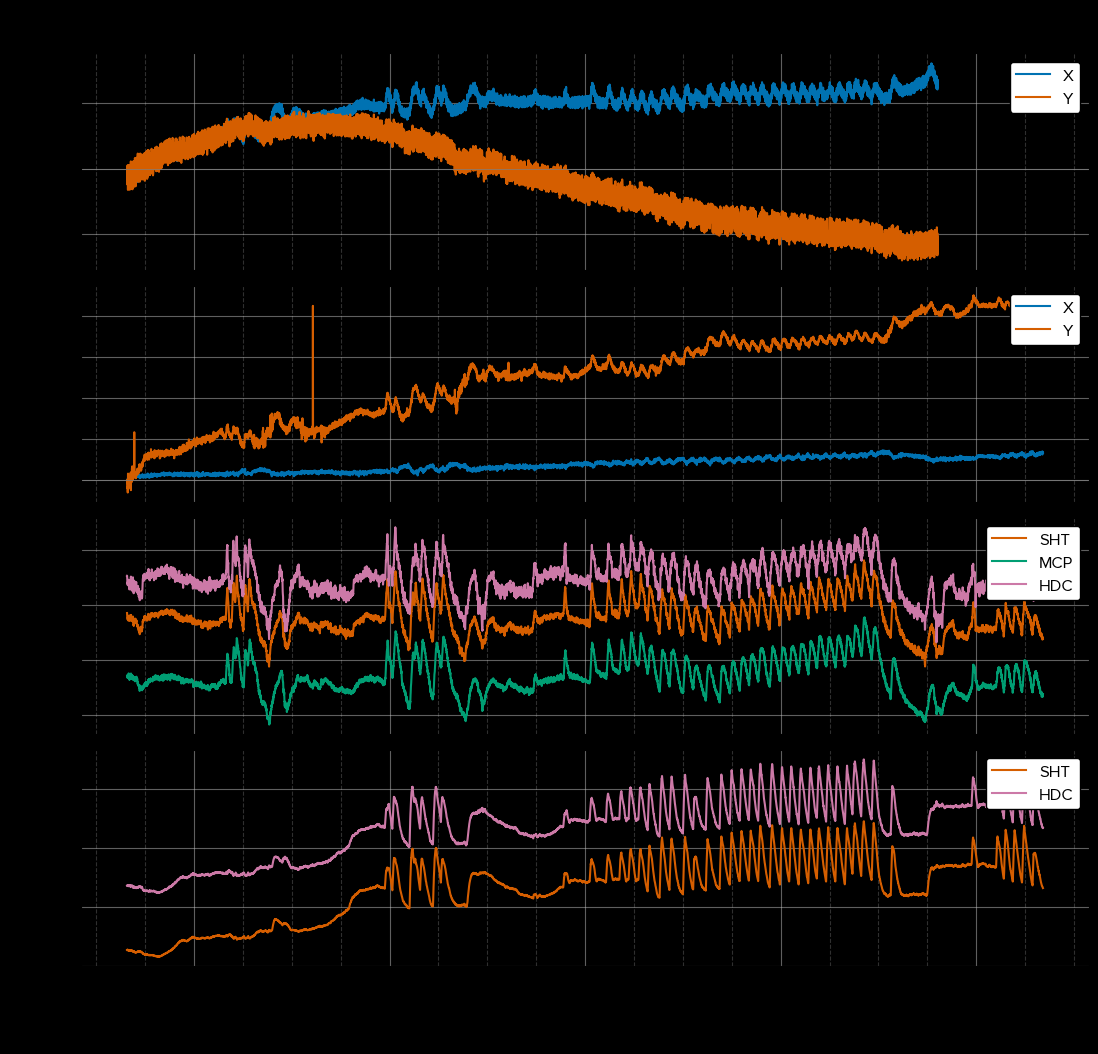

In [18]:
out_png = FULL_SYSTEM_PATH.parent / 'bridget_comparison_environment.png'
title = (f'Most Recent Test — Primary Only vs Full System\n'
         f'{t_start:%Y-%m-%d %H:%M}  →  {t_end:%Y-%m-%d %H:%M}')

fig, axes = plot_comparison(
    genie_frames, full_frames, env,
    title=title,
    out_path=out_png,
)
plt.show()